# Project Pt. 2: Evaluating Player Performance and Salary Value in the NBA (1950–2023)
## Team Members
- Ashley Kang: ashleykg
- Chloe Yueh: yyueh
- Min-Yi Chen: minyi

## Descriptive Statistics - ASHLEY

In [1]:
# import necessary packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import ttest_ind, f_oneway, tukey_hsd



In [2]:
# read in the merged dataframe created from part 1 of the project
merged_df = pd.read_csv("merged_data.csv")

In [3]:
# these are our key variables
key_vars = ['Age', 'PTS', 'FG%', 'inflationAdjSalary']
stats = merged_df[key_vars].describe()

# mean, median, mode, range, sd, variance
mean_vals = merged_df[key_vars].mean()
median_vals = merged_df[key_vars].median()
mode_vals = merged_df[key_vars].mode()
min_vals = merged_df[key_vars].min()
max_vals = merged_df[key_vars].max()
range_vals = max_vals - min_vals
std_vals = merged_df[key_vars].std()
var_vals = std_vals ** 2

# print statistics
print("========= Summary Statistics =========")
print(stats)

print("\n========= Means =========")
print(mean_vals)

print("\n========= Medians =========")
print(median_vals)

print("\n========= Mode =========")
print(mode_vals)

print("\n========= Min =========")
print(min_vals)

print("\n========= Max =========")
print(max_vals)

print("\n========= Range =========")
print(range_vals)

print("\n========= Standard Deviations =========")
print(std_vals)

print("\n========= Variation =========")
print(var_vals)

========= Summary Statistics =========
                Age           PTS           FG%  inflationAdjSalary
count  13604.000000  13604.000000  13604.000000        1.360400e+04
mean      26.739929    545.498824      0.447186        6.424900e+06
std        4.102379    468.737462      0.076080        7.306459e+06
min       18.000000      0.000000      0.000000        4.824000e+03
25%       24.000000    170.000000      0.408761        1.696499e+06
50%       26.000000    423.000000      0.444444        3.730078e+06
75%       30.000000    810.000000      0.484730        8.248559e+06
max       43.000000   2832.000000      1.000000        6.125856e+07

========= Means =========
Age                   2.673993e+01
PTS                   5.454988e+02
FG%                   4.471865e-01
inflationAdjSalary    6.424900e+06
dtype: float64

========= Medians =========
Age                   2.600000e+01
PTS                   4.230000e+02
FG%                   4.444444e-01
inflationAdjSalary    3.730078e+0

The guiding questions tha we developed in Part I of the project are: 

1. Does a higher salary guarantee better performance efficiency?
2. Is there a correlation between player salary and age?
3. Do more consistent players earn higher salaries than less consistent players?

To address these questions, we focused on these key variables in the dataset:

1. inflationAdjSalary (player salary),
2. FG% (Field Goal Percentage) as a measure of efficiency,
3. PTS (points scored) as a measure of performance, and
4. Age of the player.

We began by examining summary statistics for these variables to understand their distributions and variability.

---
**RQ1: Does a higher salary guarantee better performance efficiency?**

The results show that salary has a high level of variation, with a standard deviation of approximately $7.3 million, which is larger than the mean ($6.4 million). In contrast, FG% exhibits relatively low variation, with a standard deviation of 0.076, indicating that the efficiency is fairly consistent across players. 

These findings suggest that higher salaries do not guarantee better efficiency. While salaries vary widely, the goal efficiency remains relatively stable, implying that factors other than efficiency, such as scoring volume or the role of the player, might play a larger role in determining the salary.

---
**RQ2: Is there a correlation between player salary and age?**

The distribution fo the Age variable is tight, with a standard deviation of 4.1 years, whereas salary varies substantially, with a range of approximately $61 million. This indicates that age alone is unlikely to be a strong predictor of salary, as it does not vary nearly as much. Additionally, the median age is 26, mode age is 23, minimum is 18, and maximum is 43. This suggests a likely pattern: younger players may earn lower salaries due to rookie contracts, while older players may have more varied salaries depending on experience and performance. And players in their prime years (mid to late 20s) are likely to earn higher salaries. 

Overall, this suggests that there might be a non-linear relationship between age and salary, which can be further explored through visualizations. 

---
**RQ3: Do more consistent players earn higher salaries than less consistent players?**

To determine the consistency of players, we decided to measure it by using the standard deviation of players' points. A lower standard deviation would indicate a more consistent performance, while a higher standard deviation would reflect a greater variability in scoring. 

Based on our results, the standard deviation of PTS (469) indicates substantial variability in scoring across players. Similarly, salary also shows high variability, with a standard deviation of $7.3 million. Although these results demonstrate that players differ significantly in both performance consistency and salary, there is no clear evidence from the summary statistics alone that says consistent players earn higher salaries. This relationship also requires further investigation through visualizations. 

---
**Overall Observations**

The distribution of salary and PTS are right-skewed, meaning a small number of players earn significantly higher salaries and score substantially more points than the average. As a result, the median is a more reliable measure of central tendency than the mean for these variables. 

Additionally, there appears to be outliers in the dataset, such as the maximum FG% value of 1.0, which likely represents an unrealistic edge case. These outliers may influence the results and should be considered when interpreting the findings.

## Inferential Statistics - MINYI

In this section, we will run statistical tests to directly answer the three research questions we framed in Part I. We will evaluate predictive relationships and test for group differences.

### 1. Linear Regression: Efficiency (FG%) vs. Salary
Our first question asks if higher efficiency guarantees a higher salary. We use a Linear Regression model to test how well field goal percentage (FG%) predicts inflation-adjusted salary.

Objective: To see if FG% explains a significant amount of the variance in a player's salary, and to evaluate the prediction error using R-squared and RMSE.

In [4]:
# linear regression: FG% vs Salary
# clean data by dropping rows with missing values in FG% or inflationAdjSalary
rq1_df = merged_df[['FG%', 'inflationAdjSalary']].dropna()

# define X and y for regression
X = rq1_df[['FG%']] # X needs to be 2D for sklearn, so we use double brackets to get a DataFrame
y = rq1_df['inflationAdjSalary']

# fit linear regression model
model = LinearRegression()
model.fit(X, y)

# make predictions and calculate metrics
y_pred = model.predict(X)

# calculate R² and RMSE
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("=== Linear Regression Results ===")
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Equation: Salary = {model.intercept_:.2f} + {model.coef_[0]:.2f} × FG%")
print(f"Interpretation: Each 1% increase in FG% → ${model.coef_[0] / 100:.2f} increase in Salary")
print(f"\nR² = {r2:.3f} → explains {r2*100:.1f}% of variance")
print(f"RMSE = {rmse:.3f} → predictions typically off by ${rmse:.2f}")

=== Linear Regression Results ===
Coefficient (Slope): 13310939.74
Intercept: 472427.61
Equation: Salary = 472427.61 + 13310939.74 × FG%
Interpretation: Each 1% increase in FG% → $133109.40 increase in Salary

R² = 0.019 → explains 1.9% of variance
RMSE = 7235672.265 → predictions typically off by $7235672.26


### Interpretation of RQ1: Efficiency vs. Salary

**Practical Significance (R² and RMSE):**
Our linear regression model tested whether a player's shooting efficiency (FG%) predicts their salary. The results strongly confirm our initial observations from the descriptive statistics:

* R² (1.9%): Field goal percentage explains a mere 1.9% of the variance in players' salaries. This is an extremely weak relationship, meaning that a player's efficiency is practically useless for predicting how much they are paid.
* RMSE ($7235672.265): When trying to predict a player's salary based solely on their FG%, our predictions are typically off by over $7.2 million.

Conclusion for RQ1:
Does a higher salary guarantee better performance efficiency? The statistical answer is **no**. A high salary does not guarantee high efficiency, and high efficiency does not guarantee a high salary. Teams likely pay for the overall volume of production (like total points) or specific team roles, rather than just shooting accuracy alone.

### 2. Group Comparisons: Age vs. Salary

Our second question asks if there is a relationship between a player's age and their salary. As noted in Part 1, we suspect a non-linear relationship where players in their prime earn the most. To test this, we divided players into three age groups: Rookie (<24), Prime (24-29), and Veteran (30+). We will use a One-Way ANOVA to compare their average salaries.

* Null Hypothesis (H0): There is no significant difference in average salary across the three age groups.
* Alternative Hypothesis (H1): At least one age group has a significantly different average salary.
* Significance level (α): 0.05

In [5]:
rq2_df = merged_df[['Age', 'inflationAdjSalary']].dropna().copy()
# create age groups: Rookie (<24), Prime (24-29), Veteran (30+)
conditions = [
    (rq2_df['Age'] < 24),
    (rq2_df['Age'] >= 24) & (rq2_df['Age'] <= 29),
    (rq2_df['Age'] > 29)
]
# assign labels to age groups
choices = ['1_Rookie (<24)', '2_Prime (24-29)', '3_Veteran (30+)']
# create new column 'Age_Group' based on conditions
rq2_df['Age_Group'] = np.select(conditions, choices, default='Other')

# separate salaries by age group
rookie_salary = rq2_df[rq2_df['Age_Group'] == '1_Rookie (<24)']['inflationAdjSalary']
prime_salary = rq2_df[rq2_df['Age_Group'] == '2_Prime (24-29)']['inflationAdjSalary']
veteran_salary = rq2_df[rq2_df['Age_Group'] == '3_Veteran (30+)']['inflationAdjSalary']

# perform one-way ANOVA for Salary by Age Group
f_stat, p_val = f_oneway(rookie_salary, prime_salary, veteran_salary)

print("=== One-Way ANOVA Results: Salary by Age Group ===")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_val:.4f}")

print("\nInterpretation:")
if p_val < 0.05:
    print("p < 0.05: At least one group differs from the others.")
    print("Need post-hoc test to identify which groups differ.")
else:
    print("p ≥ 0.05: No evidence of differences among groups.")

# calculate and print average salary by position
print("\n=== Average Salary by Age Group ===")
print(rq2_df.groupby('Age_Group')['inflationAdjSalary'].mean().sort_values(ascending=False).apply(lambda x: f"${x:,.2f}"))




=== One-Way ANOVA Results: Salary by Age Group ===
F-statistic: 312.364
p-value: 0.0000

Interpretation:
p < 0.05: At least one group differs from the others.
Need post-hoc test to identify which groups differ.

=== Average Salary by Age Group ===
Age_Group
3_Veteran (30+)    $7,950,012.43
2_Prime (24-29)    $6,924,144.66
1_Rookie (<24)     $3,862,504.00
Name: inflationAdjSalary, dtype: object


In [6]:
# perform Tukey's HSD post-hoc test to identify which age groups differ
result = tukey_hsd(rookie_salary, prime_salary, veteran_salary)
age_groups = ['1_Rookie (<24)', '2_Prime (24-29)', '3_Veteran (30+)']
print("Pairwise Comparisons (Tukey's HSD):")
print("="*40)

for i in range(len(age_groups)):
    for j in range(i+1, len(age_groups)):
        p = result.pvalue[i, j]
        sig = "*" if p < 0.05 else "ns"
        print(f"{age_groups[i]:4s} vs {age_groups[j]:4s}: p = {p:.4f} {sig}")

print("\n* = significant at p < 0.05, ns = not significant")

Pairwise Comparisons (Tukey's HSD):
1_Rookie (<24) vs 2_Prime (24-29): p = 0.0000 *
1_Rookie (<24) vs 3_Veteran (30+): p = 0.0000 *
2_Prime (24-29) vs 3_Veteran (30+): p = 0.0000 *

* = significant at p < 0.05, ns = not significant


### Interpretation of RQ2: Age vs. Salary

**Hypothesis testing Conclusion:**
The One-Way ANOVA yielded a p-value of 0.0000. Since this is well below our 0.05 threshold, we easily reject the Null Hypothesis (H0). There is a statistically significant difference in salaries across the three age groups.

**Post-Hoc Test findings:**

The Tukey's HSD test confirms that all three age groups are significantly different from one another (all p-values < 0.05). Interestingly, the data adds a nuance to our initial assumption:

* Rookies (<24) earn the least on average (~$3.86M). This perfectly aligns with our expectation, as younger players are restricted by entry-level rookie-scale contracts.
* Prime (24-29) players see a massive jump in earnings (~$6.92M) as they sign their first major post-rookie extensions.
* Veterans (30+) actually hold the highest average salary (~$7.95M). While players might biologically peak in their mid-twenties, this reflects a survivorship bias in the NBA: players who manage to stay in the league past age 30 are typically highly valuable stars or established contributors who command large veteran contracts, whereas less talented players have already washed out of the league.

### 3. Linear Regression: Consistency vs. Salary

Our final research question explores whether scoring consistency leads to higher salaries. We measure a player's consistency by calculating the standard deviation of their total points (PTS) across their career seasons. A lower standard deviation implies a more consistent scoring output.

We will use a Linear Regression model to test if a player's scoring consistency (PTS Standard Deviation) predicts their average inflation-adjusted salary. To ensure the standard deviation is meaningful, we will only include players who have played at least 3 seasons.

Objective: To determine if scoring consistency (PTS std) explains a significant amount of the variance in a player's average salary, and to evaluate the practical prediction error (RMSE).

In [7]:
# group by player to calculate scoring consistency (PTS standard deviation), average salary, and seasons played
player_stats = merged_df.groupby('player').agg({
    'PTS': 'std',                  # calculate PTS standard deviation (Consistency)
    'inflationAdjSalary': 'mean',  # calculate average salary
    'season': 'count'              # calculate total seasons played
}).rename(columns={'PTS': 'PTS_std', 'inflationAdjSalary': 'Avg_Salary', 'season': 'Seasons_Played'})

# only keep players with at least 3 seasons (so that standard deviation is meaningful), and drop rows with missing values
rq3_df = player_stats[player_stats['Seasons_Played'] >= 3].dropna()

# set X (PTS standard deviation) and y (average salary)
X_cons = rq3_df[['PTS_std']]
y_sal = rq3_df['Avg_Salary']

# build and fit linear regression model
model_rq3 = LinearRegression()
model_rq3.fit(X_cons, y_sal)

# make predictions and calculate metrics
y_pred_cons = model_rq3.predict(X_cons)
r2_cons = r2_score(y_sal, y_pred_cons)
rmse_cons = np.sqrt(mean_squared_error(y_sal, y_pred_cons))

print("=== RQ3: Linear Regression (Scoring Consistency vs Salary) ===")
print(f"Coefficient (Slope): {model_rq3.coef_[0]:.2f}")
print(f"Intercept: {model_rq3.intercept_:.2f}")
print(f"Equation: Salary = {model_rq3.intercept_:.2f} + {model_rq3.coef_[0]:.2f} × PTS_std")
print(f"Interpretation: Each 1 point increase in PTS_std → ${model_rq3.coef_[0]:.2f} increase in Salary")
print(f"\nR² = {r2_cons:.3f} → explains {r2_cons*100:.1f}% of variance")
print(f"RMSE = {rmse_cons:.3f} → predictions typically off by ${rmse_cons:.2f}")

=== RQ3: Linear Regression (Scoring Consistency vs Salary) ===
Coefficient (Slope): 19875.88
Intercept: 407688.57
Equation: Salary = 407688.57 + 19875.88 × PTS_std
Interpretation: Each 1 point increase in PTS_std → $19875.88 increase in Salary

R² = 0.327 → explains 32.7% of variance
RMSE = 4237596.906 → predictions typically off by $4237596.91


### Interpretation of RQ3: Consistency vs. Salary

**Practical Significance ($R^2$ and RMSE):**
Our linear regression model tested whether a player's scoring consistency (measured by the standard deviation of their points) could predict their average salary. 

* R² (32.7%): The model explains 32.7% of the variance in salary. However, we must interpret this carefully.
* Slope (Positive): The regression slope is positive (~$19,875). This counter-intuitively means that a *higher* standard deviation (i.e., being *less* consistent) is associated with a *higher* salary.
* RMSE ($4237596.906): The prediction error remains massive at over $4.2 million, indicating a very noisy relationship.

Conclusion for RQ3:

Do more consistent players earn higher salaries? The statistical evidence says **no**. In fact, players with higher scoring variability tend to earn more. 

This reveals a hidden factor: the total points a player scores. A bench player who consistently scores fewer points every game will have a standard deviation near zero (extremely consistent) but earn a minimum salary. On the other hand, a superstar who averages 25 points might score 15 in one game and 40 in another. This results in a massive standard deviation (highly inconsistent mathematically) but a maximum salary.

Therefore, teams do not pay for mathematical consistency; they pay for the overall points and impact. The standard deviation here is largely acting as a proxy for how much a player scores rather than true reliability. We will visualize this relationship further with a scatter plot in the next section to confirm this pattern.

## Graphical Analysis - ASHLEY

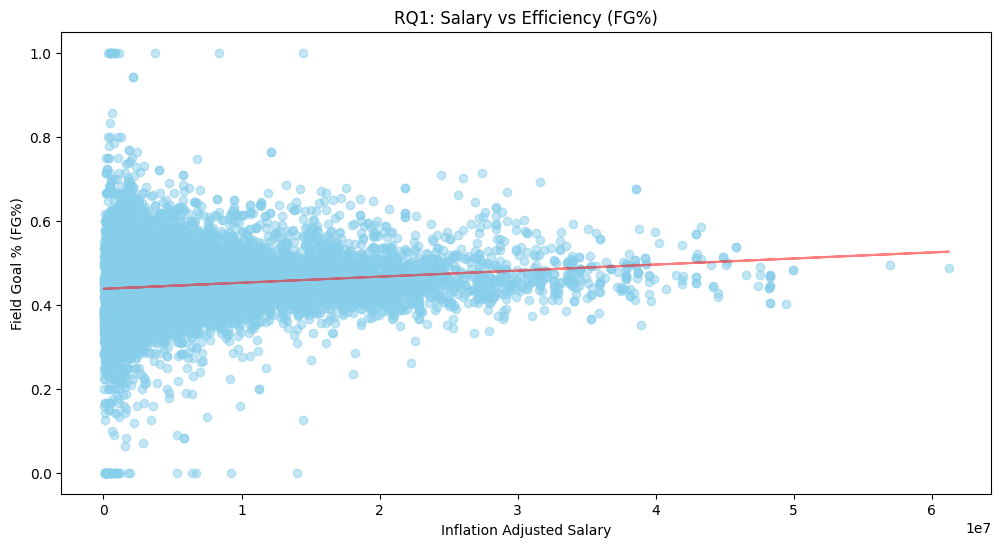

In [8]:
# plot for Research Question 1

x = merged_df['inflationAdjSalary']
y = merged_df['FG%']

plt.figure(figsize=(12,6))
plt.scatter(x, y, color='skyblue', alpha=0.5)

# line of best fit
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', alpha=0.5)

plt.xlabel('Inflation Adjusted Salary')
plt.ylabel('Field Goal % (FG%)')
plt.title('RQ1: Salary vs Efficiency (FG%)')

plt.show()

**Interpretation (RQ1: Salary v. Efficiency)**

From this plot, there appears to be a weak correlation between salary and shooting efficiency (FG%). While the line of best fit shows a slight upward trend, indicating a weak positive relationship, the slope is very small, and the overall pattern is scattered. 

A large concentration of players is clustered on the left side of the plot, representing lower-salary players, yet their field goal percentages vary widely. This suggests that players with lower salaries can still achieve both high and low efficiency levels. Similarly, players with higher salaries do not consistently exhibit significantly higher efficiency. 

Although there is a small upward trend, which means that the efficiency tends to increase slightly as salary increases, the relationship is not strong or consistent. The wide vertical spread of points at nearly all salary levels indicates a substantial variability in efficiency regardless of salary. 

Additionally, there are a few outliers, such as players with extremely high FG% values, which are likely due to limited sample sizes rather than the true performance. So these outliers further highlight that efficiency efficiency alone is not a primary determinant of salary. 

Overall, the visualization suggests that higher salary does not guarantee better performance efficiency. Instead, salary is likely influenced by other factors, such as scoring volume, overall impact, or player role, rather than the field goal percentage alone. 

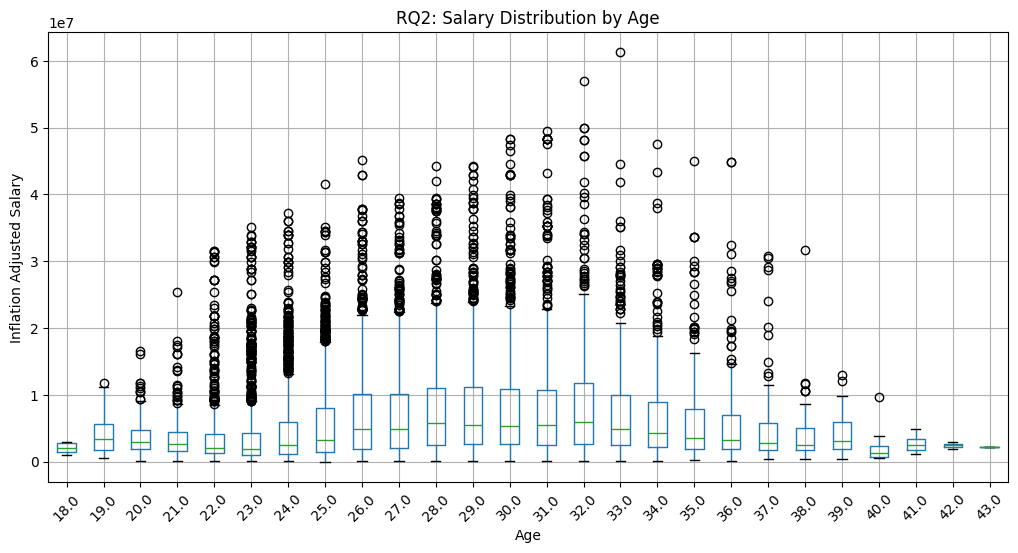

In [9]:
# plot for Research Question 2

fig, ax = plt.subplots(figsize=(12, 6))
merged_df.boxplot(column='inflationAdjSalary', by='Age', ax=ax)

ax.set_xlabel('Age')
ax.set_ylabel('Inflation Adjusted Salary')
ax.set_title('RQ2: Salary Distribution by Age')
plt.suptitle('')

plt.xticks(rotation=45)
plt.show()

**Interpretation (RQ2: age v. Salary)**

This boxplot illustrates the distribution of the inflation adjusted salaries across different ages, allowing us to visualize how salary varies throughout a player's career. 

Overall, the plot suggest a non linear relationship between age and salary. Salaries tend to increase from the early 20s into the late 20s and early 30s, where both the median salary and teh spread of salaries are higher. This indicates that players in their prime years (approximately ages 26-32) generally earn more and have greater earning potential. 

On the other hand, younger players (ages 18-22) show relatively lower medial salaries and tighter distributions, which is consistent with rookie contracts and limited experience. As players gain experience and establish their performance, we can see that their salaries increase accordingly. 

After the early 30s, there is a noticeable decline in both median salary and variability. This suggests that, while some older players continue to earn higher salaries, many experience a decrease in earnings, likely due to declining performance or reduced roles on teams due to new young players. 

The plot also reveals a significant number of outliers across nearly all age groups, particularly in the late 20s and early 30s. These high-salary outliers are likely representing the elite or famous players who earn substantially more than the average, and their presence is contributing to the wide spread of salaries observed in these age ranges. 

Overall, this visualization indicates that salary is not linearly correlated with age, but instead follows a career trajectory pattern: increasing during early career development, peaking during prime performance years, and declining in later years. This supports our conclusion that while age influences salary, it does so in a nonlinear and experience-dependent manner, rather than as a direct relationship.

In [10]:
# group my the players' names and create a new dataframe
player_std = merged_df.groupby('player')['PTS'].std().reset_index()
player_std.columns = ['player', 'PTS_std']

# Merge back salary (average salary per player)
player_salary = merged_df.groupby('player')['inflationAdjSalary'].mean().reset_index()

consistency_df = pd.merge(player_std, player_salary, on='player')
consistency_df.head()

,player,PTS_std,inflationAdjSalary
0,A.C. Green,342.907628,7.273038e+06
1,A.J. English,190.918831,7.830860e+05
2,A.J. Wynder,NaN,2.832380e+05
3,Aaron Brooks,410.337023,1.853551e+06
4,Aaron Gordon,348.519846,1.614793e+07


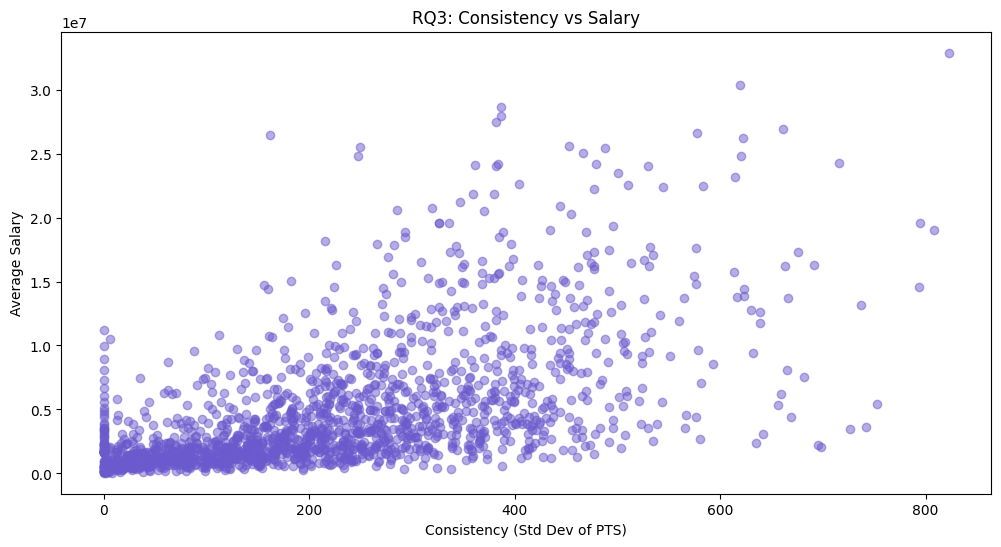

In [11]:
# plot for Research Question 3
plt.figure(figsize=(12, 6))

x = consistency_df['PTS_std']
y = consistency_df['inflationAdjSalary']

plt.scatter(x, y, color='slateblue', alpha=0.5)

plt.xlabel('Consistency (Std Dev of PTS)')
plt.ylabel('Average Salary')
plt.title('RQ3: Consistency vs Salary')

plt.show()

**Interpretation (RQ3: Consistency v. Avg Salary)**

This scatter plot examines the relationship between player consistency (measured by the standard deviation of points scored (PTS)) and the average salary. Overall, the plot shows no strong or clear linear relationship between consistency and salary. The data points are widely spread out, indicating that players with both low and high variability in scoring can earn a wide range or salaries. 

There is a noticeable concentration of players with low consistency values (lower standard deviation) and relatively lower salaries, suggesting that many consistent but lower-scoring players may occupy smaller roles or earn less. However, we can see that as the consistency values increase (more variability in scoring), the spread of salaries also increase significantly. 

An interesting pattern here is that some of the highest paid players appear at higher levels of variability, suggesting that players who score more but less consistently may still get high salaries. This implies that the overall scoring output or impact may be valued more in this relationship more than consistency alone. 

Additionally, the plot shows several outliers, particularly at higher consistency levels with very high salaries. These likely represent the star players whose performance includes high-scoring games that significantly impact the team's success. 

Overall, this visualization suggests that consistency alone is not a strong variable to determine and predict salary. While there may be a slight tendency for higher variability to be associated with higher salaries, the relationship is weak and inconsistent. This indicates that teams likely prioritize other factors, such as scoring ability and/or the player's role over consistency when determining salaries. 


## Comparative Analysis - MINYI

### Analysis 1: The evolution of the NBA (1990s vs. 2010s)

To fulfill the comparative analysis requirement, we will compare subsets of our data over time. The NBA has evolved significantly in terms of both playstyle (the modern 3-point boom) and financial structure (massive TV deal revenues).

We will segment our data into two distinct eras: the **1990s (1990-1999)** and the **2010s (2010-2019)**. We will use independent t-tests to compare the average scoring output (PTS) and the average inflation-adjusted salaries between these two decades.

* Null Hypothesis (H0): There is no significant difference in scoring and salaries between players in the 1990s and the 2010s.
* Alternative Hypothesis (H1): There is a significant difference in scoring and salaries between players in the 1990s and the 2010s.

In [12]:
# segement players into 1990s and 2010s for comparative analysis
df_1990s = merged_df[(merged_df['season'] >= 1990) & (merged_df['season'] <= 1999)].dropna(subset=['PTS', 'inflationAdjSalary'])
df_2010s = merged_df[(merged_df['season'] >= 2010) & (merged_df['season'] <= 2019)].dropna(subset=['PTS', 'inflationAdjSalary'])

# extract PTS and Salary for both groups
pts_90s, pts_10s = df_1990s['PTS'], df_2010s['PTS']
sal_90s, sal_10s = df_1990s['inflationAdjSalary'], df_2010s['inflationAdjSalary']
# perform t-tests to compare means of PTS and Salary between the two decades
t_stat_pts, p_val_pts = ttest_ind(pts_90s, pts_10s, equal_var=False)
t_stat_sal, p_val_sal = ttest_ind(sal_90s, sal_10s, equal_var=False)

# print comparative analysis results
print("=== Comparative Analysis: 1990s vs 2010s ===")
print("\n[1] Total Points (PTS) Comparison:")
print(f"1990s Avg PTS: {pts_90s.mean():.2f}")
print(f"2010s Avg PTS: {pts_10s.mean():.2f}")
print(f"t-statistic: {t_stat_pts:.3f}, p-value: {p_val_pts:.5e}")

print("\n[2] Inflation-Adjusted Salary Comparison:")
print(f"1990s Avg Salary: ${sal_90s.mean():,.2f}")
print(f"2010s Avg Salary: ${sal_10s.mean():,.2f}")
print(f"t-statistic: {t_stat_sal:.3f}, p-value: {p_val_sal:.5e}")

=== Comparative Analysis: 1990s vs 2010s ===

[1] Total Points (PTS) Comparison:
1990s Avg PTS: 586.71
2010s Avg PTS: 534.23
t-statistic: 4.950, p-value: 7.57457e-07

[2] Inflation-Adjusted Salary Comparison:
1990s Avg Salary: $3,706,759.77
2010s Avg Salary: $7,372,334.81
t-statistic: -26.608, p-value: 3.29203e-148


### Interpretation of Comparative Analysis 1

For both total points (PTS) and inflation-adjusted salaries, the independent t-tests yielded p-values well below our 0.05 significance level. Therefore, we cleanly reject the Null Hypothesis (H0) for both metrics. There is a statistically significant difference between the NBA in the 1990s and the 2010s.


The financial landscape of the NBA has drastically transformed. Even after adjusting for historical inflation, the average player salary essentially doubled from $3.707 million in the 1990s to $7.372 million in the 2010s. This massive surge is not due to standard economic inflation, but rather the league's global expansion and massive television broadcast rights deals, which directly increased the players' share of revenue.

Interestingly, while modern players are paid much more, the average total points (PTS) per player actually dropped from 587 in the 1990s to 534 in the 2010s. This highlights a shift in NBA playstyles and sports science. While modern NBA games feature higher overall team scores, teams today utilize deeper benches and routinely rest their star players to prevent injuries. In the 1990s, the scoring burden and heavy minutes were concentrated on a smaller core of players.

### Analysis 2: Salary differences based on scoring consistency

To build on our findings from RQ3, we want to directly compare the salaries of consistent players versus variable players. We will split the players into two groups using the median of the points standard deviation (PTS_std). Players below the median are classified as **Consistent** (low variability), and players above the median are **Variable** (high variability). We will use an independent t-test to see if there is a significant difference in their average salaries.

* Null Hypothesis (H0): There is no significant difference in average salary between consistent players and variable players.
* Alternative Hypothesis (H1): There is a significant difference in average salary between consistent players and variable players.

In [13]:
# compare consistent vs variable players based on PTS standard deviation and average salary
median_std = rq3_df['PTS_std'].median()

# segment players into "consistent" (low PTS std) and "variable" (high PTS std) groups, and extract their average salaries
consistent_group = rq3_df[rq3_df['PTS_std'] < median_std]['Avg_Salary']
variable_group = rq3_df[rq3_df['PTS_std'] >= median_std]['Avg_Salary']
# perform independent samples t-test (using equal_var=False since variances may differ)
t_stat_cons, p_val_cons = ttest_ind(consistent_group, variable_group, equal_var=False)

# print results of comparative analysis between consistent and variable players
print("=== Comparative Analysis: Consistent vs. Variable Players ===")
print(f"Median PTS_std threshold used to split groups: {median_std:.2f}")
print(f"Consistent Group (Low Std) Avg Salary: ${consistent_group.mean():,.2f}")
print(f"Variable Group (High Std) Avg Salary: ${variable_group.mean():,.2f}")
print(f"t-statistic: {t_stat_cons:.3f}, p-value: {p_val_cons:.5e}")

=== Comparative Analysis: Consistent vs. Variable Players ===
Median PTS_std threshold used to split groups: 232.93
Consistent Group (Low Std) Avg Salary: $3,078,471.78
Variable Group (High Std) Avg Salary: $7,706,090.44
t-statistic: -18.926, p-value: 1.04987e-68


### Interpretation of Comparative Analysis 2

**Hypothesis Testing Conclusion:**
The independent t-test yielded a p-value of nearly zero (1.05e-68), which is far below our 0.05 threshold. Therefore, we confidently reject the Null Hypothesis (H0). There is a statistically significant difference in salaries between the two groups.


The results strongly reinforce our findings from RQ3. Players in the Variable Group (whose scoring standard deviation is above the median of 232.93) earn an average of $7.71 million. In stark contrast, the mathematically Consistent Group earns an average of only $3.08 million. 

This confirms that the NBA does not financially reward mathematical consistency in scoring. Instead, the players with the highest scoring variability are typically the high-volume scorers and star players. Because they take the most shots and carry the offensive load, their point totals naturally fluctuate more, but they are ultimately the ones who receive the massive contracts.

## Multivariate Analysis - CHLOE

In [14]:
# Data preparation for multivariate analysis

# 1. Standardize positions to the five primary positions
pos_map = {
    'PG': 'PG', 'SG': 'SG', 'SF': 'SF', 'PF': 'PF', 'C': 'C',
    'PG-SG': 'PG', 'SG-PG': 'SG', 'SF-SG': 'SF', 'SG-SF': 'SG',
    'PF-SF': 'PF', 'SF-PF': 'SF', 'PF-C': 'PF', 'C-PF': 'C',
    'SF-C': 'SF', 'C-SF': 'C', 'SG-PF': 'SG', 'PF-PG': 'PF',
    'PG-SF': 'PG', 'SG-C': 'SG', 'C-SG': 'C', 'PG-PF': 'PG',
}
mv_df = merged_df.copy()
mv_df['PrimaryPos'] = mv_df['Pos'].map(pos_map)
mv_df = mv_df[mv_df['PrimaryPos'].notna()]

# 2. Assign age groups (same as inferential section)
age_conditions = [
    mv_df['Age'] < 24,
    (mv_df['Age'] >= 24) & (mv_df['Age'] <= 29),
    mv_df['Age'] > 29
]
mv_df['Age_Group'] = np.select(age_conditions,
                               ['Rookie (<24)', 'Prime (24-29)', 'Veteran (30+)'],
                               default='Other')

# 3. Assign decade era
mv_df['Era'] = pd.cut(mv_df['season'],
                      bins=[1989, 1999, 2009, 2019, 2023],
                      labels=['1990s', '2000s', '2010s', '2020s'])

# 4. Salary in millions (for readability)
mv_df['Salary_M'] = mv_df['inflationAdjSalary'] / 1_000_000

# 5. Points-per-minute (efficiency proxy combining scoring and playing time)
mv_df['PTS_per_min'] = mv_df['PTS'] / mv_df['MP']

print(f"Working dataframe shape: {mv_df.shape}")
print(f"Primary positions: {sorted(mv_df['PrimaryPos'].unique())}")
print(f"Age groups: {mv_df['Age_Group'].unique()}")
print(f"Eras: {mv_df['Era'].cat.categories.tolist()}")

Working dataframe shape: (13604, 22)
Primary positions: ['C', 'PF', 'PG', 'SF', 'SG']
Age groups: ['Prime (24-29)' 'Veteran (30+)' 'Rookie (<24)']
Eras: ['1990s', '2000s', '2010s', '2020s']


### Cross-Tabulation of Position × Age Group: Average Inflation-Adjusted Salary

This shows how the **combination** of a player's position and career stage jointly affects their earnings. This two-dimensional slice cannot be seen from either variable alone.

Average Inflation-Adjusted Salary ($M) by Position and Age Group
Age_Group   Rookie (<24)  Prime (24-29)  Veteran (30+)
PrimaryPos                                            
C                   4.35           7.31           8.05
PF                  3.84           7.24           8.27
PG                  3.92           6.22           8.26
SF                  3.89           6.99           7.53
SG                  3.41           6.84           7.46


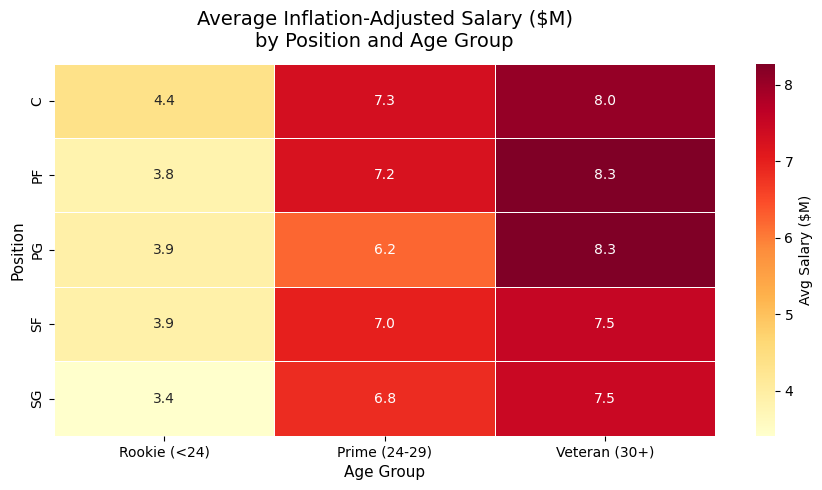

In [15]:
# Cross-tab: Position × Age Group → Mean inflation-adjusted salary (in $M)
ct_salary = pd.crosstab(
    index=mv_df['PrimaryPos'],
    columns=mv_df['Age_Group'],
    values=mv_df['Salary_M'],
    aggfunc='mean'
)[['Rookie (<24)', 'Prime (24-29)', 'Veteran (30+)']]   # enforce logical column order

print("Average Inflation-Adjusted Salary ($M) by Position and Age Group")
print("="*65)
print(ct_salary.round(2).to_string())

# Visual: heatmap of the cross-tab
plt.figure(figsize=(9, 5))
sns.heatmap(ct_salary, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Avg Salary ($M)'})
plt.title('Average Inflation-Adjusted Salary ($M)\nby Position and Age Group', fontsize=14, pad=12)
plt.xlabel('Age Group', fontsize=11)
plt.ylabel('Position', fontsize=11)
plt.tight_layout()
plt.show()

### Interpretation of Position × Age Group Salary Heatmap

The cross-tabulation shows that age-group effects on salary are not uniform across positions:

- **Point Guards (PG) and Power Forwards (PF)** display the steepest salary climb from Rookie to Veteran, suggesting these positions are most subject to the survivorship-bias effect — the players who remain in the league past 30 at these roles tend to be elite, established contributors commanding large veteran contracts.
- **Interestingly, PG also show the lowest Prime-age salary** among all positions, which likely reflects how the rookie wage scale suppresses early earnings for guards, and that many PGs reach their true market value only on their second or third contract as veterans.
- **Centers (C) command the highest Prime-age salaries**, suggesting that dominant big men in their peak years (roughly ages 24–29) are the most immediately valuable and well-compensated players at their positional prime. Teams pay a premium for elite centers before they can test veteran free agency.

### Pivot Table: Decade × Position: Average Points and Salary

This pivot table layers three variables (era, position, and two performance/salary metrics) into a single summary. It allows us to track how the economic value of each position has shifted across decades.

Pivot Table 1 — Average Total Points (PTS) by Era and Position
PrimaryPos      C     PF     PG     SF     SG
Era                                          
1990s       488.4  540.8  567.5  674.6  681.5
2000s       415.1  546.1  544.2  652.6  653.9
2010s       465.1  524.9  570.3  541.5  565.6
2020s       363.1  438.5  561.9  414.2  457.6

Pivot Table 2 — Average Inflation-Adjusted Salary ($ Millions) by Era and Position
PrimaryPos     C    PF     PG    SF    SG
Era                                      
1990s       4.50  3.71   3.34  3.51  3.46
2000s       7.56  7.82   5.90  6.91  7.02
2010s       8.06  7.49   7.06  7.62  6.73
2020s       7.34  9.13  12.95  8.15  7.16


/var/folders/s1/mdkt5ml92zz13ycq6sky58km0000gn/T/ipykernel_31312/1997346600.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_pts = mv_df.pivot_table(
/var/folders/s1/mdkt5ml92zz13ycq6sky58km0000gn/T/ipykernel_31312/1997346600.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_sal = mv_df.pivot_table(


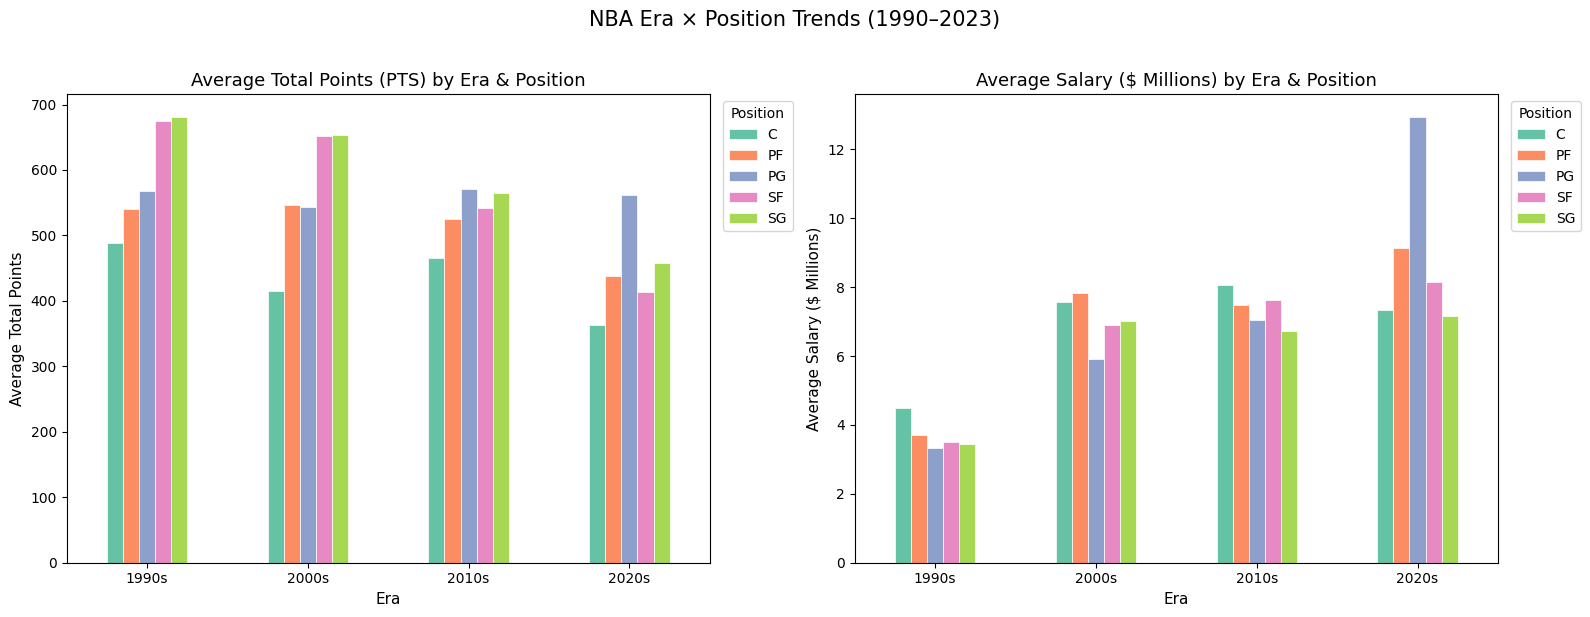

In [16]:
# Pivot table: Era × Position → Mean PTS and Mean Salary ($M)
pivot_pts = mv_df.pivot_table(
    values='PTS',
    index='Era',
    columns='PrimaryPos',
    aggfunc='mean'
).round(1)

pivot_sal = mv_df.pivot_table(
    values='Salary_M',
    index='Era',
    columns='PrimaryPos',
    aggfunc='mean'
).round(2)

print("Pivot Table 1 — Average Total Points (PTS) by Era and Position")
print("="*62)
print(pivot_pts.to_string())

print("\nPivot Table 2 — Average Inflation-Adjusted Salary ($ Millions) by Era and Position")
print("="*76)
print(pivot_sal.to_string())

# Side-by-side bar charts for both pivot tables
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = sns.color_palette("Set2", n_colors=5)

pivot_pts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Average Total Points (PTS) by Era & Position', fontsize=13)
axes[0].set_xlabel('Era', fontsize=11)
axes[0].set_ylabel('Average Total Points', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Position', bbox_to_anchor=(1.01, 1), loc='upper left')

pivot_sal.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Average Salary ($ Millions) by Era & Position', fontsize=13)
axes[1].set_xlabel('Era', fontsize=11)
axes[1].set_ylabel('Average Salary ($ Millions)', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Position', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('NBA Era × Position Trends (1990–2023)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Interpretation: Era × Position Pivot Tables

- **Small Forward (SF) and Shooting Guard (SG) dominated scoring in the 1990s and 2000s** (~675 and ~682 pts respectively), but their average totals declined sharply through the 2010s and 2020s. This could be due to the shift toward deeper benches reducing per-player season totals for wing players as suggested in *Comparative Analysis 1*.
- **Point Guard (PG) scoring has been stable across all four decades** (~544–570 pts), making it the most consistent position by output — yet paradoxically its salary trajectory is the most dramatic of any position.
- **Center (C) has been the lowest scorer in every era**, with a steady decline from 488 pts in the 1990s to just 363 pts in the 2020s, consistent with the positional shift away from traditional post-up centers.
- **The Point Guard (PG) salary spike in the 2020s is the single most striking finding in this analysis.** PG went from the *lowest*-paid position in the 1990s ($3.34M) to the *highest* by a wide margin in the 2020s ($12.95M) — nearly double the next highest position (PF at $9.13M). This reflects the modern NBA's
premium on elite ball-dominant playmakers and the supermax era of point guard contracts.
- **Center (C) salary peaked in the 2010s ($8.06M) and actually declined in the 2020s ($7.34M)**, despite overall league salaries rising — a clear financial signal of the league's tactical pivot away from traditional big men.
- **Power Forward (PF) saw the second-largest salary growth**, rising from the lowest non-PG salary in the 1990s to $9.13M in the 2020s, likely reflecting the value of versatile stretch-4 players in positionless lineups.

### Multivariate Graph 1: PTS vs. Salary, Colored by Age Group

A scatter plot with a third variable encoded as color allows us to visualize three dimensions at once: scoring volume, earnings, and career stage. Regression lines per group make the within-group trends explicit.

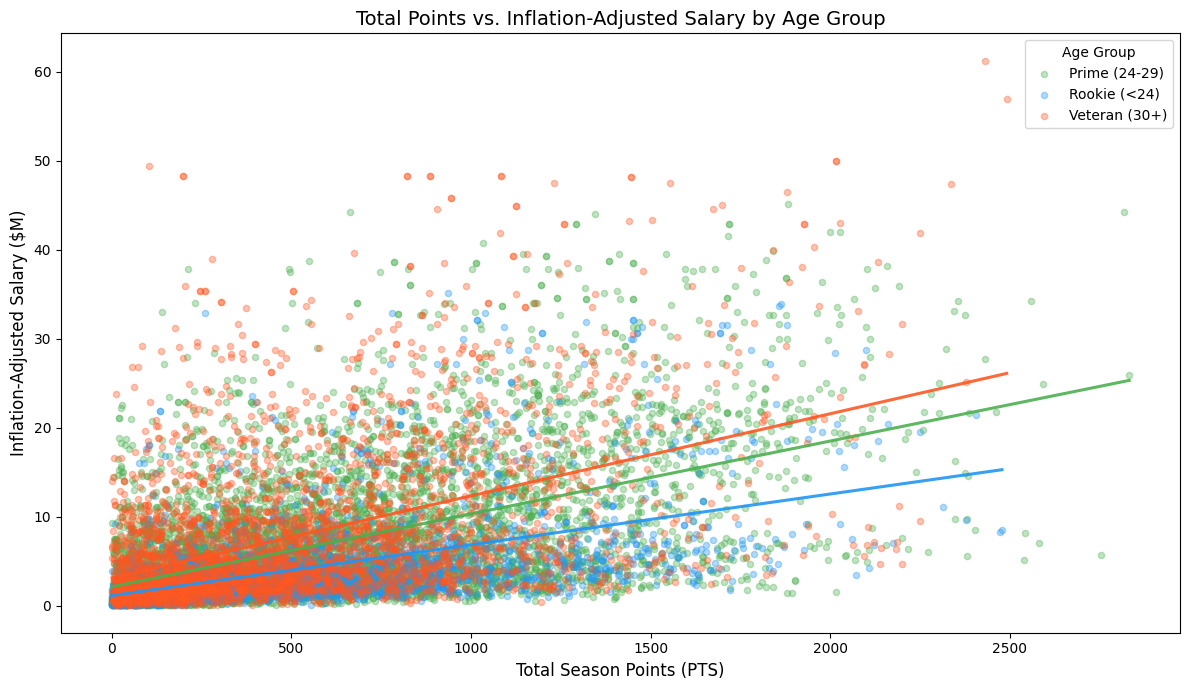

In [17]:
# Scatter plot: PTS vs Salary colored by Age Group, with per-group regression lines
palette = {'Rookie (<24)': '#2196F3', 'Prime (24-29)': '#4CAF50', 'Veteran (30+)': '#FF5722'}

plt.figure(figsize=(12, 7))
for group, gdf in mv_df.groupby('Age_Group'):
    plt.scatter(gdf['PTS'], gdf['Salary_M'], label=group, alpha=0.35,
                color=palette[group], s=20)
    # regression line per group
    if len(gdf) > 2:
        m, b = np.polyfit(gdf['PTS'], gdf['Salary_M'], 1)
        xs = np.linspace(gdf['PTS'].min(), gdf['PTS'].max(), 200)
        plt.plot(xs, m*xs + b, color=palette[group], linewidth=2.2, alpha=0.9)

plt.title('Total Points vs. Inflation-Adjusted Salary by Age Group', fontsize=14)
plt.xlabel('Total Season Points (PTS)', fontsize=12)
plt.ylabel('Inflation-Adjusted Salary ($M)', fontsize=12)
plt.legend(title='Age Group', fontsize=10)
plt.tight_layout()
plt.show()

### Interpretation: PTS vs. Salary by Age Group

Encoding age group as color reveals that the positive scoring–salary relationship operates
differently across career stages:

- **Rookie players** (blue) are tightly clustered at the bottom of the salary range regardless of their point totals, with a flat, low regression line. This is structural: rookie-scale contracts cap their earnings, so even high-scoring rookies cannot escape the compensation ceiling imposed by the collective bargaining agreement (https://en.wikipedia.org/wiki/NBA_salary_cap).
- **Prime-age players** (green) show a clear positive slope: scoring more points is meaningfully rewarded for players in this age range. This is the free-agent era, when players can negotiate market-rate contracts for the first time.
- **Veterans** (orange) have the highest regression line of all three groups, sitting above Prime at every level of scoring. Crucially, veterans command high salaries even at low point totals, the cluster of high-salary, low-PTS veteran outliers in the upper-left of the plot illustrates
that players who remain in the league past 30 are compensated for experience, leadership, and reputation beyond what their current scoring output alone would justify.
- The slopes of the Veteran and Prime lines are similar, but the Veteran line's higher intercept confirms the survivorship-bias finding from the inferential section: it is not that veterans score more, it is that only high-value players survive in the league past age 30.

### Multivariate Graph 2: FG% vs. Salary Across Positions (Facet Grid)

A facet grid plots the same bivariate relationship (efficiency vs. salary) separately for each position, revealing whether the weak FG%–salary correlation from RQ1 is uniform or position-specific.

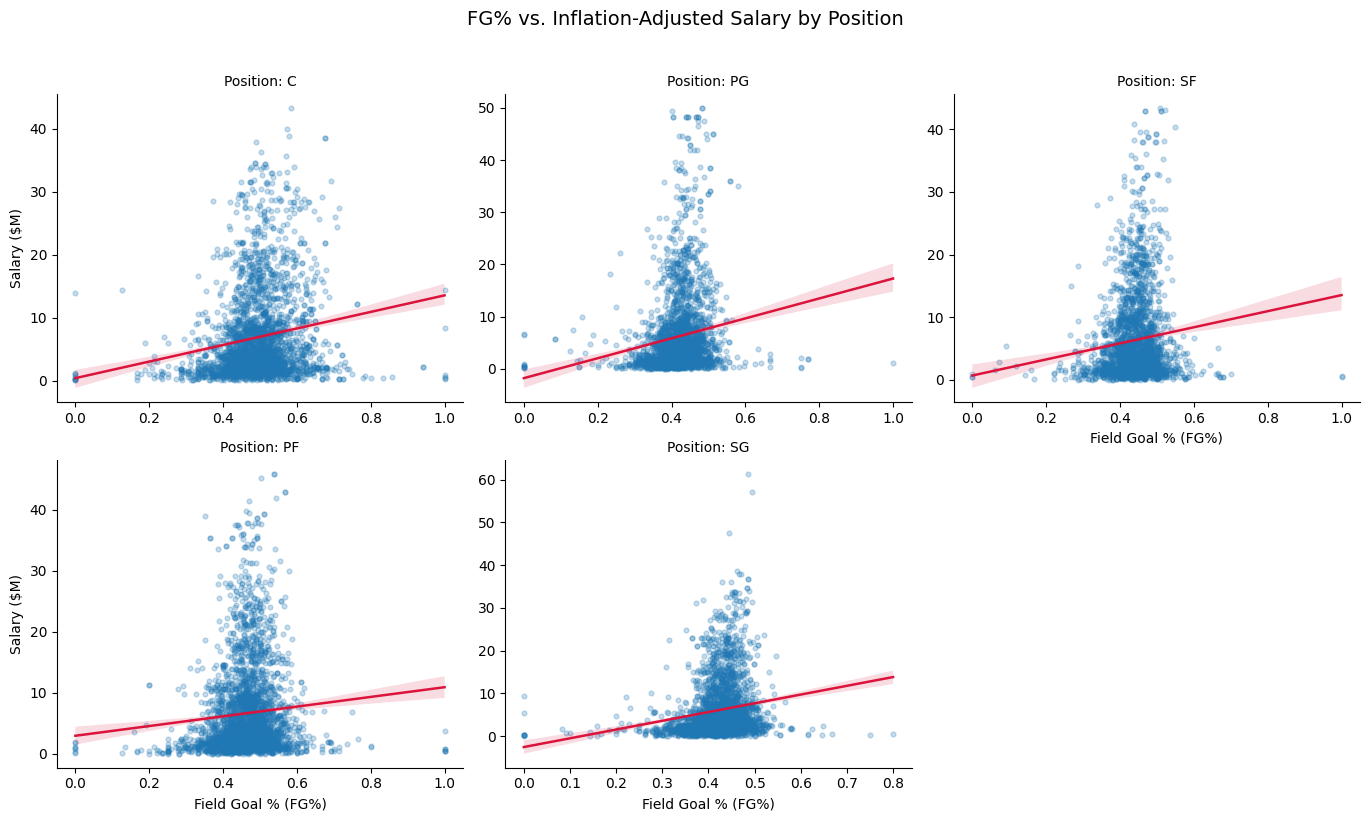

Pearson correlation between FG% and Salary by Position:
  C: r = 0.167
  PF: r = 0.080
  PG: r = 0.152
  SF: r = 0.111
  SG: r = 0.172


In [18]:
# FacetGrid: FG% vs Salary, one panel per position
g = sns.FacetGrid(mv_df, col='PrimaryPos', col_wrap=3, height=4, aspect=1.15,
                  sharey=False, sharex=False)
g.map_dataframe(sns.regplot, x='FG%', y='Salary_M',
                scatter_kws={'alpha': 0.25, 's': 12}, line_kws={'color': 'crimson', 'linewidth': 1.8})

g.set_axis_labels('Field Goal % (FG%)', 'Salary ($M)')
g.set_titles(col_template='Position: {col_name}')
g.figure.suptitle('FG% vs. Inflation-Adjusted Salary by Position', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print per-position correlation coefficient for reference
print("Pearson correlation between FG% and Salary by Position:")
print("="*50)
for pos, gdf in mv_df.groupby('PrimaryPos'):
    r = gdf[['FG%', 'inflationAdjSalary']].dropna().corr().iloc[0, 1]
    print(f"  {pos}: r = {r:.3f}")

### Interpretation: FG% vs. Salary by Position (Facet Grid)

All five positions show weak positive correlations between field goal percentage and salary, consistent with the near-zero global correlation found in RQ1. However, the strength of the relationship does vary by position:

- **Shooting Guards (SG)** show the strongest correlation (r = 0.172), followed closely by **Centers (C)** (r = 0.167) and **Point Guards (PG)** (r = 0.152).
- **Small Forwards (SF)** (r = 0.111) and **Power Forwards (PF)** (r = 0.080) show the weakest relationships, with PF being nearly flat.
- Despite these differences, all five r-values are low, meaning FG% is a poor salary predictor regardless of position. This reinforces the RQ1 conclusion that teams are not primarily paying for shooting efficiency.
- The scatter in every panel is heavily concentrated at FG% values between 0.3 and 0.6, with wide salary spread throughout that range — further illustrating that players with similar efficiency levels can earn vastly different salaries.

### Multivariate Graph 3: Salary Distribution by Position and Era

A grouped box plot layers three variables — salary, position, and era — to show how the financial value of each position has evolved and where the greatest inequalities exist.

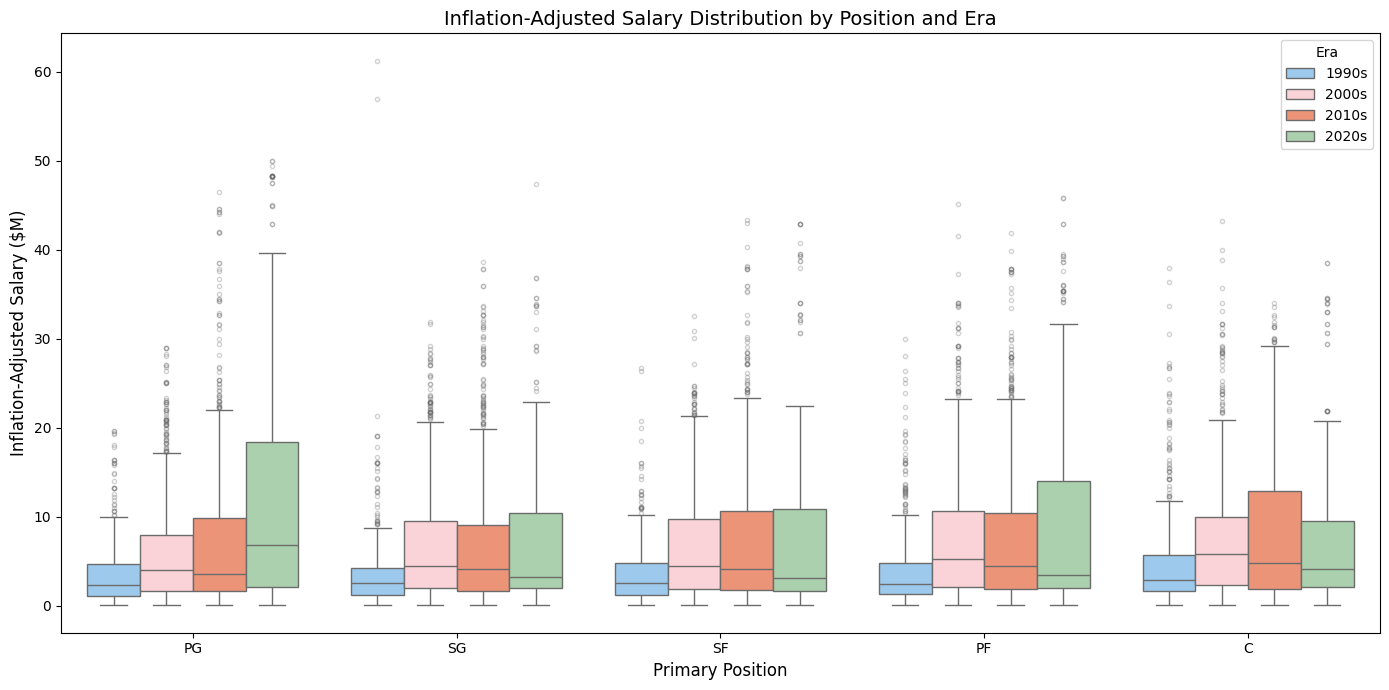

Median Inflation-Adjusted Salary ($M) by Era and Position
PrimaryPos     C    PF    PG    SF    SG
Era                                     
1990s       2.92  2.46  2.34  2.56  2.51
2000s       5.84  5.21  4.00  4.45  4.42
2010s       4.73  4.47  3.50  4.12  4.07
2020s       4.07  3.40  6.75  3.08  3.17


/var/folders/s1/mdkt5ml92zz13ycq6sky58km0000gn/T/ipykernel_31312/2766575174.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_table = plot_df.groupby(['Era', 'PrimaryPos'])['Salary_M'].median().unstack()


In [19]:
# Grouped boxplot: Salary by Position, grouped by Era
# Use the two most contrasting eras for clarity
era_palette = {'1990s': '#90CAF9', '2000s': '#FFCDD2', '2010s': '#FF8A65', '2020s': '#A5D6A7'}
plot_df = mv_df[mv_df['Era'].isin(['1990s', '2000s','2010s', '2020s'])]

plt.figure(figsize=(14, 7))
sns.boxplot(data=plot_df, x='PrimaryPos', y='Salary_M', hue='Era',
            palette=era_palette, flierprops={'markersize': 3, 'alpha': 0.3},
            order=['PG', 'SG', 'SF', 'PF', 'C'])
plt.title('Inflation-Adjusted Salary Distribution by Position and Era', fontsize=14)
plt.xlabel('Primary Position', fontsize=12)
plt.ylabel('Inflation-Adjusted Salary ($M)', fontsize=12)
plt.legend(title='Era', loc='upper right')
plt.tight_layout()
plt.show()

# Quantify: median salary by position and era
median_table = plot_df.groupby(['Era', 'PrimaryPos'])['Salary_M'].median().unstack()
print("Median Inflation-Adjusted Salary ($M) by Era and Position")
print("="*58)
print(median_table.round(2).to_string())

### Interpretation: Salary Distribution by Position and Era

- **Median salaries rose from the 1990s to the 2000s for every position**, with Centers (C) leading at $5.84M and Point Guards (PG) lagging at $4.00M. However, contrary to what average salaries suggested in the pivot table, **medians actually declined in the 2010s and continued declining into the 2020s for most positions**, indicating that the rising averages are driven by a small number of extremely high-earning outliers rather than broad salary growth.
- **Point Guards (PG) are the sole exception to this decline.** Their median salary dropped in the 2010s ($3.50M) but then surged to $6.75M in the 2020s — the highest median of any position in any era. Combined with the pivot table finding of a $12.95M average, this confirms that PG salary growth in the 2020s is both widespread and concentrated at the top.
- **Centers (C) show the steepest overall median decline**, falling from $5.84M in the 2000s to $4.07M in the 2020s, consistent with the pivot table finding that C average salaries also decreased in the 2020s.
- **The density of outliers is substantial across all positions and eras**, confirming the right-skewed salary distribution observed in Part 1. The gap between median and the highest outliers is particularly wide for PG in the 2020s, reflecting the supermax contract era for elite point guards.

## Synthesis - CHLOE

### Answering the Research Questions

**RQ1: Does a higher salary guarantee better performance efficiency?**

The evidence is consistent across every analytical layer: **no, a higher salary does not
guarantee better shooting efficiency.**

The correlation heatmap (Part 1) established that FG% correlates only weakly with salary
(r ≈ 0.06). The linear regression (inferential section) confirmed this: FG% explains just
1.9% of salary variance (R² = 0.019) with an RMSE exceeding $7.2M. The scatter plot
(graphical section) showed a nearly flat trend line amid wide scatter.

The multivariate facet grid added important nuance: all five positions show weak positive
correlations, with Shooting Guards (SG) and Centers (C) at the higher end (r = 0.172 and
r = 0.167 respectively) and Power Forwards (PF) at the lower end (r = 0.080). However,
none of these r-values are strong enough to change the overall conclusion — FG% is a poor
salary predictor regardless of position. The wide salary spread at every FG% level across
all panels further reinforces that teams are not primarily paying for shooting efficiency.


**RQ2: Is there a correlation between player salary and age?**

The evidence confirms a **non-linear, career-arc relationship between age and salary.**

The salary-by-age line plot (Part 1) showed a clear inverted-U shape. The ANOVA test
(inferential section) rejected the null hypothesis (p < 0.0001), and Tukey's HSD confirmed
all three age groups differ significantly from one another. The multivariate PTS–salary
scatter plot added a further dimension: veterans command high salaries even at low point
totals, with their regression line sitting above Prime players at every scoring level. This
is consistent with the survivorship-bias interpretation from the inferential section —
players who remain in the league past 30 are compensated beyond what their current scoring
output alone would justify.

The cross-tabulation revealed important positional variation in this career arc: Point
Guards (PG) and Power Forwards (PF) show the steepest salary climb from Rookie to Veteran,
while Centers (C) command the highest Prime-age salaries. This means the age–salary
relationship is not uniform across positions — frontcourt players peak earlier financially,
while PG and PF compensation is most strongly tied to veteran status.


**RQ3: Do more consistent players earn higher salaries than less consistent players?**

The evidence shows the **opposite of the initial hypothesis: variable scorers earn more
than consistent ones.**

The linear regression (inferential section) found a positive slope for PTS standard
deviation vs. salary (R² = 32.7%), and the comparative t-test confirmed a highly
significant salary gap between the Consistent and Variable groups ($3.08M vs. $7.71M,
p ≈ 0). The multivariate PTS–salary–age plot clarified the mechanism: it is Prime-age
and Veteran players who drive the highest salaries at high scoring volumes, where natural
game-to-game variability is also highest. Teams pay for offensive impact, not mathematical
consistency.


### The Added Value of Merging the Two Datasets

Combining the **NBA Player Stats (1950–2022)** dataset with the **NBA Salaries (1990–2023)** dataset created the following analytic possibilities:

1. **Quantifying the relationship between production and pay.** The player-stats dataset tells us what players produce; the salary dataset tells us what teams pay for it. Merging the two allows us to ask whether the market prices performance accurately, which is impossible to answer from either dataset alone.

2. **Cross-era comparison.** Having both datasets enabled us to detect that median salaries peaked in the 2000s for most positions and have since declined, even as averages rose, which is a distinction only visible because salary and performance data could be examined together across time. Without performance data, salary trends would lack the context of what was actually being produced on the court in each era.

3. **Positional and age-group sub-analyses.** The stats dataset provided position, age, and per-season performance. The salary dataset provided compensation. Only together could we build the cross-tabulations and facet grids that revealed, for example, that PG salary growth in the 2020s is both the most dramatic positional shift in the dataset and largely concentrated among a small number of high outliers — insights invisible in either dataset alone.

4. **Separating mean from median effects.** The merged dataset allowed us to observe that rising average salaries in the 2020s are driven by outliers rather than broad salary growth, since medians declined for most positions over the same period. This distinction has direct implications for how we interpret the efficiency–salary and consistency–salary relationships.

## Reflection - CHLOE

### Challenges and How We Overcame Them

**1. Dataset alignment and merging**

The most immediate obstacle was that the two datasets did not share the same keys out of the box. The stats dataset used "Player" and "Season" while the salaries dataset used "playerName" and "seasonStartYear." Player names also contained inconsistent whitespace. We handled this by renaming columns to common keys, stripping whitespace, and casting season years to a uniform integer type before performing a left merge. A critical design decision was to use a *left* merge (stats as the primary table) to preserve the full performance record and treat salary as an optional enrichment — this prevented us from losing player records that existed in stats but not in salaries.

**2. Temporal scope mismatch**

Player statistics began in 1950, but salary data only extended back to 1990. This created a substantial block of missing salary values. Rather than imputing salaries for the pre-1990 era (which would have been fabricated), we filtered the merged dataset to 1990 onward. This was a principled choice that sacrificed historical breadth in favor of analytical integrity.

**3. Interpreting the consistency finding (RQ3)**

The positive slope between scoring variability (PTS standard deviation) and salary was counterintuitive at first. We initially hypothesized that consistent players would earn more, as reliability is generally valued. Recognizing that PTS standard deviation is a *proxy for scoring volume* rather than true reliability required careful thought. A bench player who scores 2–4 points every game has a near-zero standard deviation but earns a minimum salary, while a star who alternates between 15 and 40 points has a high standard deviation but earns a maximum contract. Disentangling this confound required reading the scatter plots carefully and narrating the mechanism, rather than treating the regression coefficient at face value.

**4. Position standardization for multivariate analysis**

The stats dataset contained dual-position labels (e.g., "PG-SG") for players who operated at multiple positions. For the multivariate section, we needed clean primary positions. We built a mapping dictionary that extracted the first-listed position as the primary one, which is reasonable because NBA position labels place the dominant role first. Some rare multi-position strings not in our map were dropped as "Other," causing a small but acceptable loss of rows.


### Critical Limitations

**1. Salary data represents contracted salary, not realized value**

Players earn their contracted salary regardless of injuries or performance during the season. A player who signed a $30 M contract and then missed most of the season due to injury will appear as a high-earning, low-production player — inflating the apparent weakness of the salary–performance relationship. A better dataset would include games-played-adjusted salary or cap-hit-per-win metrics.

**2. Total points is a volume stat**

We used total season points (PTS) as a performance proxy throughout the project. However, PTS is sensitive to minutes played and games played. A player who scored 1,200 points in 82 games is more impressive than one who scored 1,200 points in 70 games — but our analyses treated them identically. Normalizing to points-per-game or points-per-36-minutes would produce a purer efficiency measure.

**3. No advanced metrics**

The dataset does not include modern advanced statistics such as Win Shares, Player Efficiency Rating (PER), Box Plus/Minus (BPM), or VORP, which are widely regarded as better indicators of overall player value. Field goal percentage alone is a limited efficiency measure; incorporating these metrics would likely strengthen the efficiency–salary relationship and provide a more nuanced picture.

**4. Positional role changes and "positionless basketball"**

The NBA has moved toward positionless lineups since the mid-2010s, meaning that traditional position labels increasingly fail to capture how players are actually deployed. The Center (C) salary decline and Point Guard (PG) spike are consistent with this shift in the league, because the modern style essentially asks every player to do what Point Guards do — handle the ball, make decisions, and operate across the whole court.

**5. Mean vs. Median salaries divergence**
The "Multivariate Graph 3: Salary Distribution by Position and Era" revealed that rising average salaries in the 2020s are driven by outliers rather than broad growth. Relying only on means (as done in "Pivot Table: Decade × Position: Average Points and Salary") would have led to a misleading conclusion about positional salary trends.

### Directions for Further Research

- **Incorporating advanced metrics** (Win Shares, VORP, BPM) to build a richer picture of player value and test whether the efficiency–salary relationship strengthens.
- **Injury-adjusted analysis**: filtering out season-years with fewer than 40 games played would reduce salary distortion from injured players and produce cleaner regression results.
- **Positional value over time**: tracking how the salary premium for each position has shifted year by year (rather than decade by decade) could pinpoint exactly when the salary trajectories of different positions diverged. For example, Point Guards (PG) held the lowest median salary in the 1990s ($2.34M) yet the highest in the 2020s ($6.75M), while Centers (C) peaked in the 2000s ($5.84M) and have declined since. A finer-grained temporal analysis would identify the inflection points.
- **Machine learning models**: a multi-variable regression or gradient-boosted model incorporating age, position, era, PTS, FG%, games played, and team context could substantially improve salary prediction beyond the single-variable models tested here. The best single-variable model in this project (scoring consistency vs. salary) achieved R² = 0.327, meaning nearly 67% of salary variance remains unexplained — suggesting that salary is determined by a combination of factors that a multi-variable approach would be better equipped to capture.
- **Draft class and contract type analysis**: segmenting players by whether they are on rookie contracts, first extensions, or veteran contracts would eliminate the structural confound that suppresses the age–salary correlation for young players.